# Step 4 — Non-DL Baseline

**Task:** binary classification — GG3+ (label=1) vs GG0–2 (label=0)

**Pipeline:**
1. Fixed patient-level test set (15% of subjects) — held out for final comparison with DL
2. Feature extraction from each sparse point cloud `(coords, intensity)`
3. 5-fold stratified group CV on the remaining 85% — no val set needed for simple classifiers
4. Train final model on all non-test data, evaluate on test set
5. Evaluate: ROC-AUC, PR-AUC, sensitivity/specificity

**Features extracted (37 total):**
- Global intensity statistics: mean, std, skew, kurtosis, percentiles, range (12)
- Axial intensity profile — mean and std per bin, **5 bins** (~100 voxels/bin, ≈20% of needle each) (10)
- Radial zonal contrast — core (r<1mm) vs periphery (1–2mm) (4)
- Voxel count (1)
- **Gradient magnitude** — k-NN approximation: mean |ΔI|/distance per voxel → global stats (4)
- **Local variance** — mean per-voxel k-NN neighbourhood variance (granularity proxy) (1)
- **Axial gradient profile** — mean gradient magnitude per axial bin, 5 bins (5)

In [19]:
import sys
sys.path.insert(0, '..')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path
from scipy.stats import skew, kurtosis
from scipy.spatial import KDTree
from tqdm.notebook import tqdm

from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier
from sklearn.svm import SVC
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.model_selection import GroupShuffleSplit, StratifiedGroupKFold
from sklearn.metrics import (
    roc_auc_score, average_precision_score,
    roc_curve, precision_recall_curve,
    classification_report, confusion_matrix,
)

REPO_ROOT   = Path('..').resolve()
PATCHES_DIR = REPO_ROOT / 'data' / 'patches'
MANIFEST    = REPO_ROOT / 'data' / 'manifest.csv'
DROP_LIST   = REPO_ROOT / 'data' / 'cores_to_drop_contamination.csv'

## 1. Load manifest

In [5]:
manifest = pd.read_csv(MANIFEST)
drop_ids = set(pd.read_csv(DROP_LIST)['core_id'])
manifest = manifest[~manifest['core_id'].isin(drop_ids)].reset_index(drop=True)

# Keep only cores that were successfully extracted
extracted = {int(p.stem) for p in PATCHES_DIR.glob('*.npz')}
manifest  = manifest[manifest['core_id'].isin(extracted)].reset_index(drop=True)

print(f'Cores available : {len(manifest):,}')
print(f'  label=0 : {(manifest.label==0).sum():,}')
print(f'  label=1 : {(manifest.label==1).sum():,}')
print(f'  subjects: {manifest.subject_id.nunique()}')

Cores available : 16,690
  label=0 : 16,043
  label=1 : 647
  subjects: 796


## 2. Patient-level test split + CV setup

- **Test set (15% of subjects):** fixed, identical to what the DL model will use for final comparison.
- **Trainval (85%):** used for 5-fold stratified group CV — all cores of a subject stay in the same fold.

In [6]:
np.random.seed(42)

# Subject-level positive flag for stratified splitting
subj_label = manifest.groupby('subject_id')['label'].max().reset_index()
subj_label.columns = ['subject_id', 'subj_positive']
subjects = subj_label['subject_id'].values
subj_pos = subj_label['subj_positive'].values

# Fixed 15% test set — held out, never used for model selection
splitter = GroupShuffleSplit(n_splits=1, test_size=0.15, random_state=42)
trainval_idx, test_idx = next(splitter.split(subjects, subj_pos, groups=subjects))

test_subjs    = set(subjects[test_idx])
trainval_subjs = set(subjects[trainval_idx])

manifest['split'] = manifest['subject_id'].map(
    lambda s: 'test' if s in test_subjs else 'trainval'
)

# Save test subject list so DL notebook uses the exact same split
pd.Series(sorted(test_subjs)).to_csv('../data/test_subjects.csv', index=False, header=False)

for split in ['trainval', 'test']:
    sub = manifest[manifest['split'] == split]
    pos = (sub['label'] == 1).sum()
    print(f'{split:9s}: {len(sub):6d} cores  ({sub.subject_id.nunique():3d} subjects)'
          f'  pos={pos} ({100*pos/len(sub):.1f}%)')

trainval :  14192 cores  (676 subjects)  pos=521 (3.7%)
test     :   2498 cores  (120 subjects)  pos=126 (5.0%)


## 3. Feature extraction

Each core → fixed-length feature vector from its `(coords, intensity)` point cloud.

In [7]:
N_AXIAL_BINS = 5    # bins along normalised needle axis (≈20% of needle per bin, ~100 voxels each)
CORE_RADIUS  = 1.0  # mm — threshold between core and periphery zones
K_NEIGHBORS  = 8   # k-NN for local gradient / variance estimation


def extract_features(core_id: int) -> np.ndarray | None:
    """
    Load one patch and extract a fixed-length feature vector.

    Feature groups:
      [ 0–11]  Global intensity statistics (12)
      [12–16]  Axial profile — mean intensity per bin (5)
      [17–21]  Axial profile — std  intensity per bin (5)
      [22–25]  Radial zones — mean/std for core (r<1mm) and periphery (1–2mm) (4)
      [26]     Total voxel count (1)
      [27–30]  Gradient magnitude statistics: mean, std, p50, p90 (4)
      [31]     Mean local variance — granularity proxy (1)
      [32–36]  Axial gradient profile — mean gradient magnitude per bin (5)
    Total: 37 features
    """
    path = PATCHES_DIR / f'{core_id}.npz'
    if not path.exists():
        return None

    data      = np.load(path)
    coords    = data['coords']     # (N, 3): (w, u, v)
    intensity = data['intensity']  # (N,)

    if len(intensity) < 5:
        return None

    w = coords[:, 0]
    r = np.sqrt(coords[:, 1]**2 + coords[:, 2]**2)  # radial distance

    # ── Global intensity statistics ──────────────────────────────────────────
    pcts = np.percentile(intensity, [5, 10, 25, 50, 75, 90, 95])
    feat_global = np.array([
        intensity.mean(),
        intensity.std(),
        float(skew(intensity)),
        float(kurtosis(intensity)),
        pcts[0], pcts[1], pcts[2], pcts[3], pcts[4], pcts[5], pcts[6],
        float(intensity.max() - intensity.min()),  # range
    ], dtype=np.float32)

    # ── Axial intensity profile (normalised axis [0,1] → N_AXIAL_BINS bins) ─
    w_min, w_max = w.min(), w.max()
    w_norm = (w - w_min) / (w_max - w_min + 1e-8)
    bin_idx = np.clip((w_norm * N_AXIAL_BINS).astype(int), 0, N_AXIAL_BINS - 1)

    axial_mean = np.zeros(N_AXIAL_BINS, dtype=np.float32)
    axial_std  = np.zeros(N_AXIAL_BINS, dtype=np.float32)
    for b in range(N_AXIAL_BINS):
        vals = intensity[bin_idx == b]
        if len(vals) > 0:
            axial_mean[b] = vals.mean()
            axial_std[b]  = vals.std()
        else:
            axial_mean[b] = intensity.mean()
            axial_std[b]  = 0.0

    # ── Radial zone contrast ─────────────────────────────────────────────────
    core_mask   = r < CORE_RADIUS
    periph_mask = ~core_mask
    core_vals   = intensity[core_mask]   if core_mask.any()   else intensity
    periph_vals = intensity[periph_mask] if periph_mask.any() else intensity

    feat_radial = np.array([
        core_vals.mean(),   periph_vals.mean(),
        core_vals.std(),    periph_vals.std(),
    ], dtype=np.float32)

    # ── Voxel count ──────────────────────────────────────────────────────────
    feat_count = np.array([float(len(intensity))], dtype=np.float32)

    # ── Gradient magnitude (k-NN approximation) ──────────────────────────────
    k = min(K_NEIGHBORS, len(intensity) - 1)
    tree = KDTree(coords)
    dists, idxs = tree.query(coords, k=k + 1)
    dists = dists[:, 1:]
    idxs  = idxs[:, 1:]

    delta_i   = np.abs(intensity[idxs] - intensity[:, None])
    safe_dist = np.maximum(dists, 1e-4)
    grad_mag  = (delta_i / safe_dist).mean(axis=1)

    feat_gradient = np.array([
        grad_mag.mean(),
        grad_mag.std(),
        float(np.percentile(grad_mag, 50)),
        float(np.percentile(grad_mag, 90)),
    ], dtype=np.float32)

    # ── Local variance — granularity proxy ───────────────────────────────────
    local_var    = np.var(intensity[idxs], axis=1)
    feat_texture = np.array([local_var.mean()], dtype=np.float32)

    # ── Axial gradient profile ────────────────────────────────────────────────
    axial_grad = np.zeros(N_AXIAL_BINS, dtype=np.float32)
    for b in range(N_AXIAL_BINS):
        vals = grad_mag[bin_idx == b]
        axial_grad[b] = vals.mean() if len(vals) > 0 else grad_mag.mean()

    return np.concatenate([
        feat_global, axial_mean, axial_std, feat_radial, feat_count,
        feat_gradient, feat_texture, axial_grad,
    ])


FEATURE_NAMES = (
    ['mean', 'std', 'skew', 'kurt',
     'p5', 'p10', 'p25', 'p50', 'p75', 'p90', 'p95', 'range'] +
    [f'axial_mean_{i}' for i in range(N_AXIAL_BINS)] +
    [f'axial_std_{i}'  for i in range(N_AXIAL_BINS)] +
    ['core_mean', 'periph_mean', 'core_std', 'periph_std', 'n_voxels'] +
    ['grad_mean', 'grad_std', 'grad_p50', 'grad_p90'] +
    ['local_var'] +
    [f'axial_grad_{i}' for i in range(N_AXIAL_BINS)]
)

print(f'Feature vector length: {len(FEATURE_NAMES)}')
print(FEATURE_NAMES)

Feature vector length: 37
['mean', 'std', 'skew', 'kurt', 'p5', 'p10', 'p25', 'p50', 'p75', 'p90', 'p95', 'range', 'axial_mean_0', 'axial_mean_1', 'axial_mean_2', 'axial_mean_3', 'axial_mean_4', 'axial_std_0', 'axial_std_1', 'axial_std_2', 'axial_std_3', 'axial_std_4', 'core_mean', 'periph_mean', 'core_std', 'periph_std', 'n_voxels', 'grad_mean', 'grad_std', 'grad_p50', 'grad_p90', 'local_var', 'axial_grad_0', 'axial_grad_1', 'axial_grad_2', 'axial_grad_3', 'axial_grad_4']


In [8]:
# Build feature matrix
rows = []
for _, row in tqdm(manifest.iterrows(), total=len(manifest), desc='Extracting features'):
    feat = extract_features(int(row.core_id))
    if feat is None:
        continue
    rows.append({'core_id': row.core_id, 'label': row.label, 'split': row.split,
                 'subject_id': row.subject_id, **dict(zip(FEATURE_NAMES, feat))})

feat_df = pd.DataFrame(rows)
print(f'Feature matrix: {feat_df.shape}')
feat_df[FEATURE_NAMES].describe().round(3)

Extracting features:   0%|          | 0/16690 [00:00<?, ?it/s]

Feature matrix: (16690, 41)


,mean,std,skew,kurt,p5,p10,p25,p50,p75,p90,...,grad_mean,grad_std,grad_p50,grad_p90,local_var,axial_grad_0,axial_grad_1,axial_grad_2,axial_grad_3,axial_grad_4
count,16690.000,16690.000,16690.000,16690.000,16690.000,16690.000,16690.000,16690.000,16690.000,16690.000,...,16690.000,16690.000,16690.000,16690.000,16690.000,16690.000,16690.000,16690.000,16690.000,16690.000
mean,0.347,0.712,0.661,0.701,-0.634,-0.480,-0.173,0.249,0.779,1.320,...,0.428,0.235,0.374,0.743,0.168,0.430,0.430,0.421,0.428,0.433
std,0.527,0.300,0.603,2.039,0.321,0.345,0.412,0.544,0.721,0.888,...,0.144,0.104,0.127,0.275,0.141,0.202,0.200,0.187,0.183,0.200
min,-0.950,0.084,-2.169,-1.867,-1.598,-1.598,-1.344,-1.078,-0.883,-0.650,...,0.061,0.031,0.054,0.097,0.002,0.042,0.045,0.037,0.055,0.044
25%,0.000,0.509,0.275,-0.410,-0.852,-0.711,-0.441,-0.103,0.292,0.714,...,0.329,0.171,0.285,0.560,0.081,0.289,0.290,0.288,0.299,0.307
50%,0.269,0.666,0.605,0.152,-0.660,-0.509,-0.220,0.162,0.659,1.181,...,0.414,0.219,0.361,0.711,0.136,0.394,0.394,0.392,0.401,0.406
75%,0.601,0.858,0.980,1.095,-0.451,-0.290,0.027,0.491,1.124,1.770,...,0.512,0.278,0.450,0.886,0.216,0.531,0.528,0.519,0.525,0.525
max,4.656,4.380,6.821,57.540,2.447,2.595,3.643,4.643,6.387,8.782,...,2.483,3.769,1.689,6.519,4.388,2.818,2.076,2.073,2.499,7.947


## 4. 5-fold group CV + final test evaluation

In [30]:
trainval_df = feat_df[feat_df['split'] == 'trainval']
test_df     = feat_df[feat_df['split'] == 'test']

X_tv = trainval_df[FEATURE_NAMES].values.astype(np.float32)
y_tv = trainval_df['label'].values
g_tv = trainval_df['subject_id'].values   # groups for CV

X_test = test_df[FEATURE_NAMES].values.astype(np.float32)
y_test = test_df['label'].values

print(f'Trainval: {X_tv.shape}  pos={y_tv.sum()} ({100*y_tv.mean():.1f}%)')
print(f'Test    : {X_test.shape}  pos={y_test.sum()} ({100*y_test.mean():.1f}%)')

Trainval: (14192, 37)  pos=521 (3.7%)
Test    : (2498, 37)  pos=126 (5.0%)


In [31]:
N_FOLDS = 5
cv = StratifiedGroupKFold(n_splits=N_FOLDS, shuffle=True, random_state=42)

model_specs = {
    'Logistic Regression': Pipeline([
        ('scaler', StandardScaler()),
        ('clf',    LogisticRegression(class_weight='balanced', max_iter=1000, C=1.0)),
    ]),
    'Random Forest': Pipeline([
        ('scaler', StandardScaler()),
        ('clf',    RandomForestClassifier(
            n_estimators=500, class_weight='balanced',
            min_samples_leaf=5, n_jobs=-1, random_state=42,
        )),
    ]),
    'XGBoost': Pipeline([
        ('scaler', StandardScaler()),
        ('clf',    XGBClassifier(
            n_estimators=300, max_depth=3, learning_rate=0.05,
            subsample=0.8, scale_pos_weight=25,
            eval_metric='auc', random_state=42,
            verbosity=0,
        )),
    ]),
    'SVM (RBF)': Pipeline([
        ('scaler', StandardScaler()),
        ('clf',    SVC(kernel='rbf', class_weight='balanced',
                       probability=True, C=10.0, gamma='scale')),
    ]),
}

cv_results = {}
for name, pipe in model_specs.items():
    fold_aucs, fold_aps = [], []
    oof_ids   = np.empty(len(X_tv), dtype=int)
    oof_probs = np.empty(len(X_tv), dtype=np.float32)

    for fold, (tr, va) in enumerate(cv.split(X_tv, y_tv, groups=g_tv)):
        pipe.fit(X_tv[tr], y_tv[tr])
        prob = pipe.predict_proba(X_tv[va])[:, 1]
        oof_ids[va]   = trainval_df.iloc[va]['core_id'].values
        oof_probs[va] = prob
        fold_aucs.append(roc_auc_score(y_tv[va], prob))
        fold_aps.append(average_precision_score(y_tv[va], prob))

    # Refit on all trainval for final test evaluation
    pipe.fit(X_tv, y_tv)
    prob_test = pipe.predict_proba(X_test)[:, 1]

    cv_results[name] = {
        'pipe':       pipe,
        'prob_test':  prob_test,
        'oof_ids':    oof_ids,
        'oof_probs':  oof_probs,
        'cv_auc':     np.mean(fold_aucs),
        'cv_auc_std': np.std(fold_aucs),
        'cv_ap':      np.mean(fold_aps),
        'cv_ap_std':  np.std(fold_aps),
        'test_auc':   roc_auc_score(y_test, prob_test),
        'test_ap':    average_precision_score(y_test, prob_test),
    }
    r = cv_results[name]
    print(f'{name:<25}  CV AUC={r["cv_auc"]:.3f}±{r["cv_auc_std"]:.3f}'
          f'  test AUC={r["test_auc"]:.3f}')

print()
print(f'{"Model":<25} {"CV ROC-AUC":>16} {"CV PR-AUC":>14} {"Test ROC-AUC":>13} {"Test PR-AUC":>12}')
print('-' * 82)
for name, r in cv_results.items():
    print(f'{name:<25} {r["cv_auc"]:.3f}±{r["cv_auc_std"]:.3f}  '
          f'{r["cv_ap"]:.3f}±{r["cv_ap_std"]:.3f}  '
          f'{r["test_auc"]:>13.3f}  {r["test_ap"]:>12.3f}')

Logistic Regression        CV AUC=0.596±0.044  test AUC=0.583
Random Forest              CV AUC=0.593±0.034  test AUC=0.577
XGBoost                    CV AUC=0.558±0.047  test AUC=0.598
SVM (RBF)                  CV AUC=0.570±0.035  test AUC=0.524

Model                           CV ROC-AUC      CV PR-AUC  Test ROC-AUC  Test PR-AUC
----------------------------------------------------------------------------------
Logistic Regression       0.596±0.044  0.053±0.012          0.583         0.070
Random Forest             0.593±0.034  0.055±0.013          0.577         0.062
XGBoost                   0.558±0.047  0.052±0.013          0.598         0.065
SVM (RBF)                 0.570±0.035  0.049±0.005          0.524         0.053


## 5. ROC and Precision-Recall curves

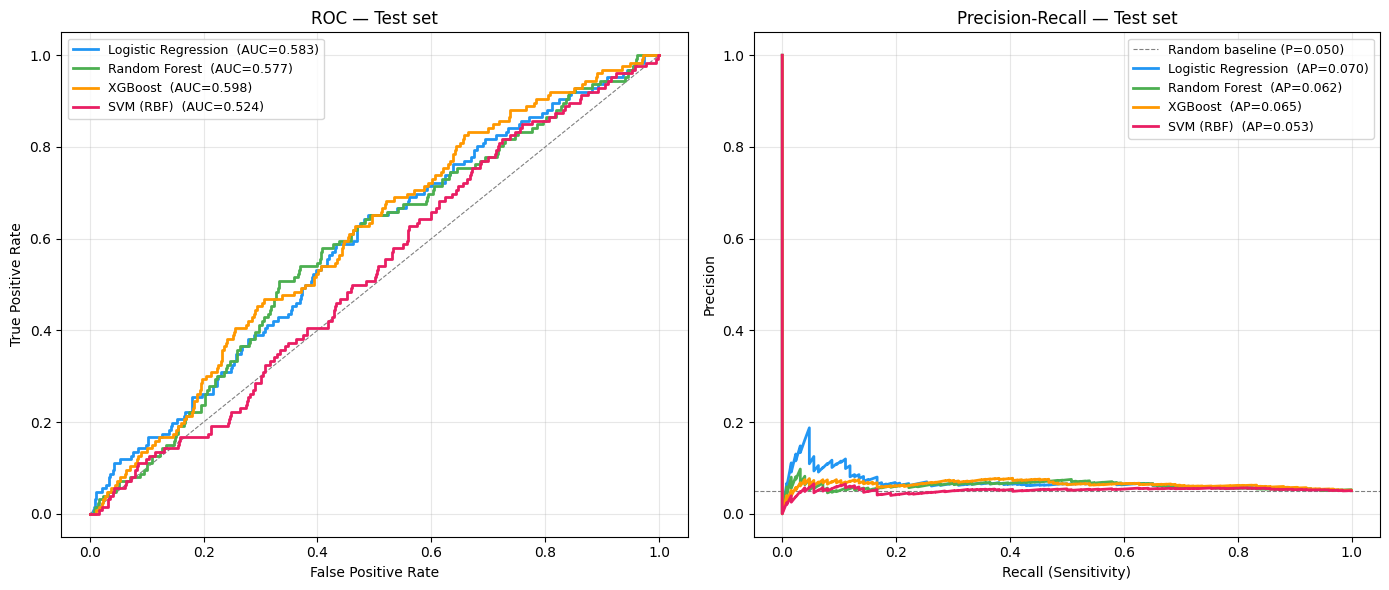

In [32]:
COLORS = ['#2196F3', '#4CAF50', '#FF9800', '#E91E63']

fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# ROC curves
ax = axes[0]
ax.plot([0,1],[0,1],'--', color='gray', linewidth=0.8)
for (name, r), c in zip(cv_results.items(), COLORS):
    fpr, tpr, _ = roc_curve(y_test, r['prob_test'])
    ax.plot(fpr, tpr, color=c, linewidth=2,
            label=f'{name}  (AUC={r["test_auc"]:.3f})')
ax.set_xlabel('False Positive Rate'); ax.set_ylabel('True Positive Rate')
ax.set_title('ROC — Test set'); ax.legend(fontsize=9); ax.grid(alpha=0.3)

# PR curves
ax = axes[1]
baseline_pr = y_test.mean()
ax.axhline(baseline_pr, linestyle='--', color='gray', linewidth=0.8,
           label=f'Random baseline (P={baseline_pr:.3f})')
for (name, r), c in zip(cv_results.items(), COLORS):
    prec, rec, _ = precision_recall_curve(y_test, r['prob_test'])
    ax.plot(rec, prec, color=c, linewidth=2,
            label=f'{name}  (AP={r["test_ap"]:.3f})')
ax.set_xlabel('Recall (Sensitivity)'); ax.set_ylabel('Precision')
ax.set_title('Precision-Recall — Test set'); ax.legend(fontsize=9); ax.grid(alpha=0.3)

plt.tight_layout()
plt.savefig('../data/baseline_curves.png', dpi=150, bbox_inches='tight')
plt.show()

## 6. Best model — operating point analysis

Best model by CV AUC, evaluated on the held-out test set.

In [33]:
best_name = max(cv_results, key=lambda n: cv_results[n]['cv_auc'])
best      = cv_results[best_name]
print(f'Best model (by CV AUC): {best_name}')
print(f'  CV   ROC-AUC = {best["cv_auc"]:.3f} ± {best["cv_auc_std"]:.3f}')
print(f'  Test ROC-AUC = {best["test_auc"]:.3f}   PR-AUC = {best["test_ap"]:.3f}')
print()

fpr, tpr, thresholds = roc_curve(y_test, best['prob_test'])
specificity = 1 - fpr

print(f'{"Specificity":>12} {"Sensitivity":>12} {"Threshold":>10}')
print('-' * 38)
for target_spec in [0.70, 0.75, 0.80, 0.85, 0.90, 0.95]:
    idx = np.argmin(np.abs(specificity - target_spec))
    print(f'{specificity[idx]:>12.3f} {tpr[idx]:>12.3f} {thresholds[idx]:>10.3f}')

J = tpr - fpr
best_idx    = np.argmax(J)
best_thresh = thresholds[best_idx]
y_pred = (best['prob_test'] >= best_thresh).astype(int)

print(f'\nYouden optimal threshold: {best_thresh:.3f}')
print(f'  Sensitivity: {tpr[best_idx]:.3f}   Specificity: {specificity[best_idx]:.3f}')
print()
print('Confusion matrix (rows=true, cols=pred):')
cm = confusion_matrix(y_test, y_pred)
print(pd.DataFrame(cm, index=['true_0','true_1'], columns=['pred_0','pred_1']))
print()
print(classification_report(y_test, y_pred, target_names=['GG0-2', 'GG3+']))

Best model (by CV AUC): Logistic Regression
  CV   ROC-AUC = 0.596 ± 0.044
  Test ROC-AUC = 0.583   PR-AUC = 0.070

 Specificity  Sensitivity  Threshold
--------------------------------------
       0.696        0.389      0.558
       0.750        0.317      0.579
       0.803        0.254      0.598
       0.847        0.198      0.619
       0.901        0.143      0.652
       0.946        0.111      0.685

Youden optimal threshold: 0.490
  Sensitivity: 0.651   Specificity: 0.512

Confusion matrix (rows=true, cols=pred):
        pred_0  pred_1
true_0    1214    1158
true_1      44      82

              precision    recall  f1-score   support

       GG0-2       0.97      0.51      0.67      2372
        GG3+       0.07      0.65      0.12       126

    accuracy                           0.52      2498
   macro avg       0.52      0.58      0.39      2498
weighted avg       0.92      0.52      0.64      2498



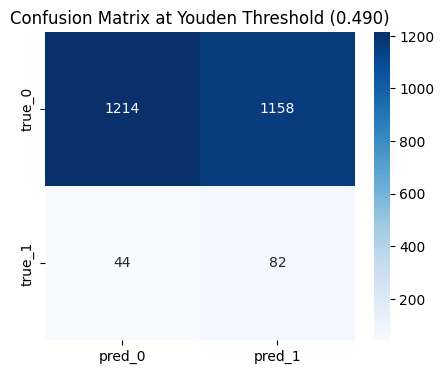

In [34]:
### confusion matrix heatmap
import seaborn as sns
plt.figure(figsize=(5,4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['pred_0', 'pred_1'], yticklabels=['true_0', 'true_1'])
plt.title(f'Confusion Matrix at Youden Threshold ({best_thresh:.3f})')
plt.savefig('../data/baseline_confusion_matrix.png', dpi=150, bbox_inches='tight')
plt.show()

## 7. Feature importance (Random Forest)

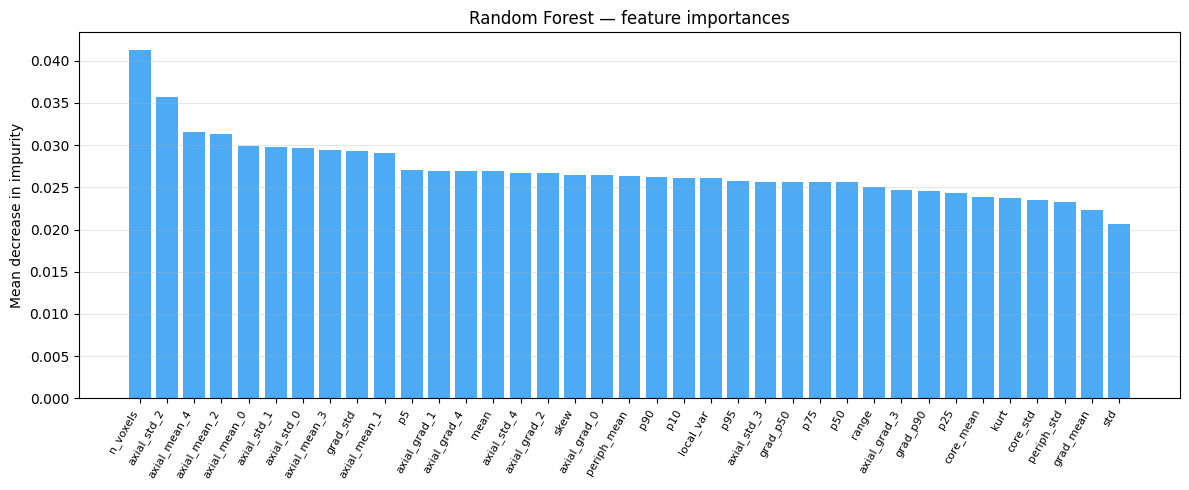

Top 10 features:
  n_voxels             0.0413
  axial_std_2          0.0357
  axial_mean_4         0.0315
  axial_mean_2         0.0313
  axial_mean_0         0.0299
  axial_std_1          0.0298
  axial_std_0          0.0296
  axial_mean_3         0.0294
  grad_std             0.0293
  axial_mean_1         0.0291


In [35]:
rf_pipe = cv_results['Random Forest']['pipe']
importances = rf_pipe.named_steps['clf'].feature_importances_
order = np.argsort(importances)[::-1]

fig, ax = plt.subplots(figsize=(12, 5))
ax.bar(range(len(FEATURE_NAMES)), importances[order], color='#2196F3', alpha=0.8)
ax.set_xticks(range(len(FEATURE_NAMES)))
ax.set_xticklabels([FEATURE_NAMES[i] for i in order], rotation=60, ha='right', fontsize=8)
ax.set_ylabel('Mean decrease in impurity')
ax.set_title('Random Forest — feature importances')
ax.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.show()

print('Top 10 features:')
for i in order[:10]:
    print(f'  {FEATURE_NAMES[i]:<20} {importances[i]:.4f}')

## 8. Intensity distribution: GG3+ vs GG0–2

Visual sanity check: do cancer cores look different in T2 intensity?

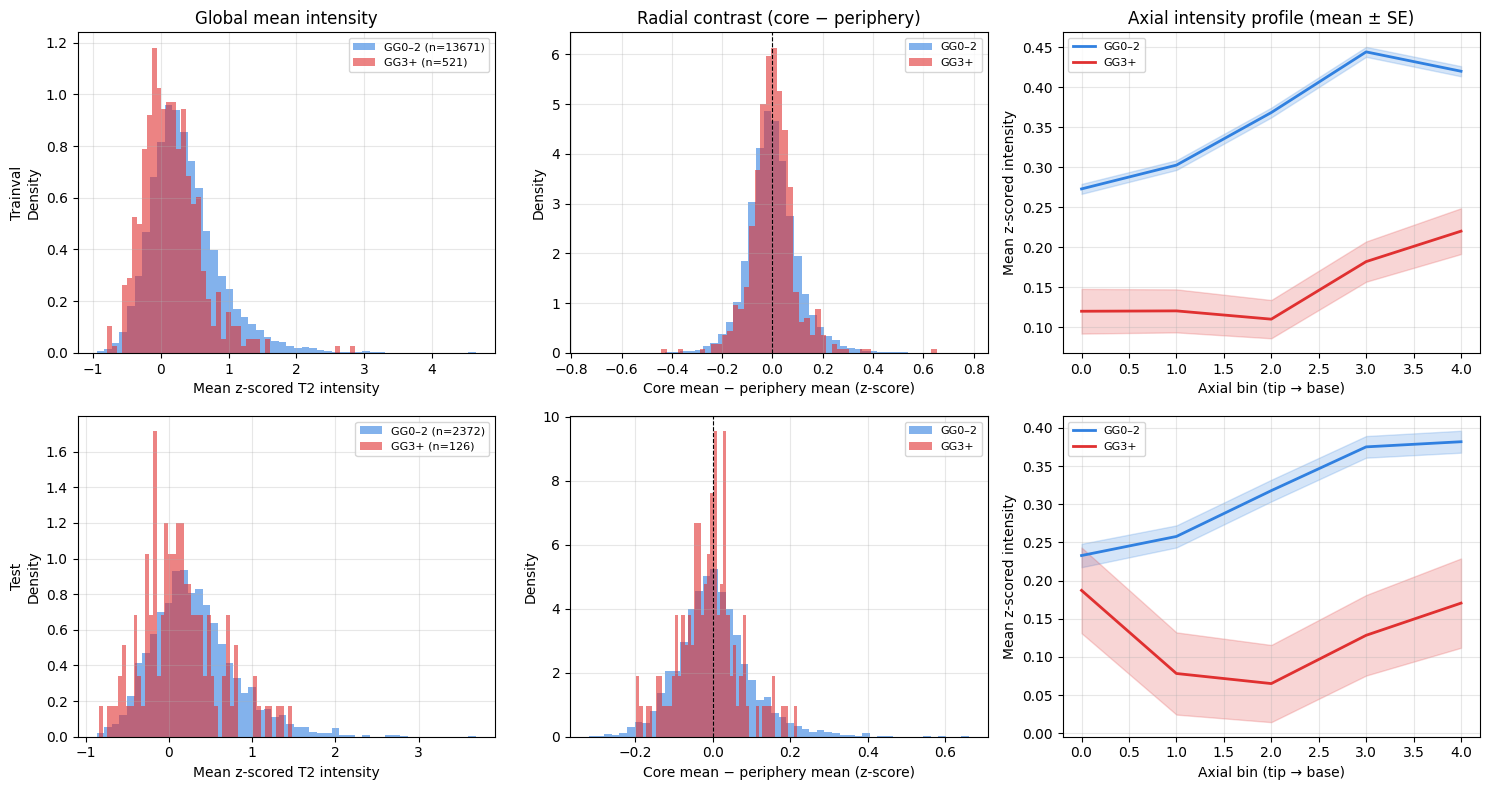

In [37]:
fig, axes = plt.subplots(2, 3, figsize=(15, 8))

for row, (split, split_label) in enumerate([('trainval', 'Trainval'), ('test', 'Test')]):
    df_split = feat_df[feat_df['split'] == split]

    # ── Global mean intensity ────────────────────────────────────────────────
    ax = axes[row, 0]
    for label, color, name in [(0, '#3080e0', 'GG0–2'), (1, '#e03030', 'GG3+')]:
        vals = df_split[df_split['label'] == label]['mean'].values
        ax.hist(vals, bins=50, alpha=0.6, color=color, density=True, label=f'{name} (n={len(vals)})')
    ax.set_xlabel('Mean z-scored T2 intensity')
    ax.set_ylabel(f'{split_label}\nDensity')
    if row == 0:
        ax.set_title('Global mean intensity')
    ax.legend(fontsize=8); ax.grid(alpha=0.3)

    # ── Core vs periphery contrast ───────────────────────────────────────────
    ax = axes[row, 1]
    for label, color, name in [(0, '#3080e0', 'GG0–2'), (1, '#e03030', 'GG3+')]:
        sub = df_split[df_split['label'] == label]
        contrast = sub['core_mean'] - sub['periph_mean']
        ax.hist(contrast.values, bins=50, alpha=0.6, color=color, density=True, label=name)
    ax.axvline(0, color='black', linewidth=0.8, linestyle='--')
    ax.set_xlabel('Core mean − periphery mean (z-score)')
    ax.set_ylabel('Density')
    if row == 0:
        ax.set_title('Radial contrast (core − periphery)')
    ax.legend(fontsize=8); ax.grid(alpha=0.3)

    # ── Axial intensity profile ──────────────────────────────────────────────
    ax = axes[row, 2]
    bins_cols = [f'axial_mean_{i}' for i in range(N_AXIAL_BINS)]
    x = np.arange(N_AXIAL_BINS)
    for label, color, name in [(0, '#3080e0', 'GG0–2'), (1, '#e03030', 'GG3+')]:
        sub = df_split[df_split['label'] == label][bins_cols]
        m  = sub.mean().values
        se = sub.sem().values
        ax.plot(x, m, color=color, linewidth=2, label=name)
        ax.fill_between(x, m - se, m + se, color=color, alpha=0.2)
    ax.set_xlabel('Axial bin (tip → base)')
    ax.set_ylabel('Mean z-scored intensity')
    if row == 0:
        ax.set_title('Axial intensity profile (mean ± SE)')
    ax.legend(fontsize=8); ax.grid(alpha=0.3)

plt.tight_layout()
plt.savefig('../data/baseline_intensity_dist.png', dpi=150, bbox_inches='tight')
plt.show()

## 9. Texture / gradient distribution: GG3+ vs GG0–2

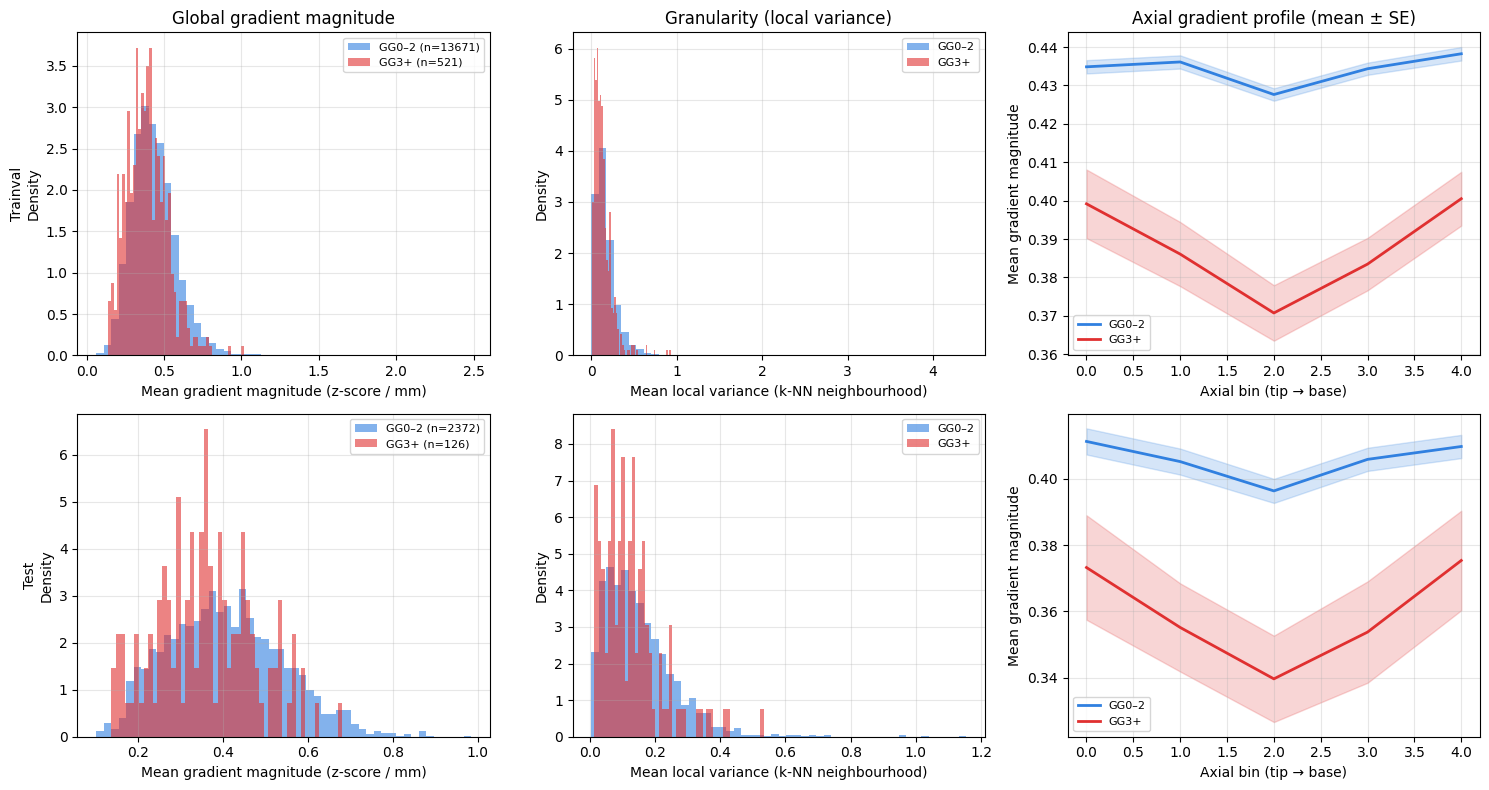

In [38]:
fig, axes = plt.subplots(2, 3, figsize=(15, 8))

for row, (split, split_label) in enumerate([('trainval', 'Trainval'), ('test', 'Test')]):
    df_split = feat_df[feat_df['split'] == split]

    # ── Global gradient magnitude ────────────────────────────────────────────
    ax = axes[row, 0]
    for label, color, name in [(0, '#3080e0', 'GG0–2'), (1, '#e03030', 'GG3+')]:
        vals = df_split[df_split['label'] == label]['grad_mean'].values
        ax.hist(vals, bins=50, alpha=0.6, color=color, density=True, label=f'{name} (n={len(vals)})')
    ax.set_xlabel('Mean gradient magnitude (z-score / mm)')
    ax.set_ylabel(f'{split_label}\nDensity')
    if row == 0:
        ax.set_title('Global gradient magnitude')
    ax.legend(fontsize=8); ax.grid(alpha=0.3)

    # ── Local variance (granularity) ─────────────────────────────────────────
    ax = axes[row, 1]
    for label, color, name in [(0, '#3080e0', 'GG0–2'), (1, '#e03030', 'GG3+')]:
        vals = df_split[df_split['label'] == label]['local_var'].values
        ax.hist(vals, bins=50, alpha=0.6, color=color, density=True, label=name)
    ax.set_xlabel('Mean local variance (k-NN neighbourhood)')
    ax.set_ylabel('Density')
    if row == 0:
        ax.set_title('Granularity (local variance)')
    ax.legend(fontsize=8); ax.grid(alpha=0.3)

    # ── Axial gradient profile ───────────────────────────────────────────────
    ax = axes[row, 2]
    bins_cols = [f'axial_grad_{i}' for i in range(N_AXIAL_BINS)]
    x = np.arange(N_AXIAL_BINS)
    for label, color, name in [(0, '#3080e0', 'GG0–2'), (1, '#e03030', 'GG3+')]:
        sub = df_split[df_split['label'] == label][bins_cols]
        m  = sub.mean().values
        se = sub.sem().values
        ax.plot(x, m, color=color, linewidth=2, label=name)
        ax.fill_between(x, m - se, m + se, color=color, alpha=0.2)
    ax.set_xlabel('Axial bin (tip → base)')
    ax.set_ylabel('Mean gradient magnitude')
    if row == 0:
        ax.set_title('Axial gradient profile (mean ± SE)')
    ax.legend(fontsize=8); ax.grid(alpha=0.3)

plt.tight_layout()
plt.savefig('../data/baseline_gradient_dist.png', dpi=150, bbox_inches='tight')
plt.show()

## 10. Predicted class by true Gleason Grade

Best model: Logistic Regression  |  Using OOF (CV) (14192 cores)
Optimal threshold (Youden J): 0.478


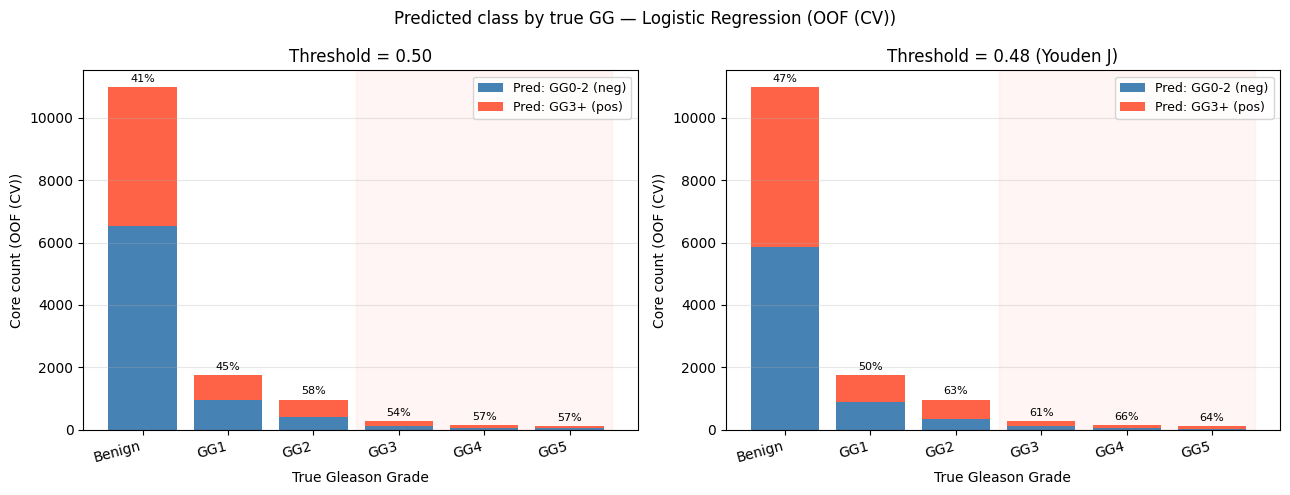

In [39]:
# Uses OOF predictions from best model (by CV AUC) if available,
# otherwise falls back to test-set predictions.
best_name = max(cv_results, key=lambda n: cv_results[n]['cv_auc'])
best      = cv_results[best_name]

USE_OOF = 'oof_probs' in best

if USE_OOF:
    pred_df = pd.DataFrame({
        'core_id': best['oof_ids'],
        'prob':    best['oof_probs'],
    })
    pred_df = pred_df.merge(manifest[['core_id', 'gleason_grade', 'label']], on='core_id')
    source_label = 'OOF (CV)'
else:
    pred_df = test_df[['core_id', 'label']].copy()
    pred_df['prob'] = best['prob_test']
    pred_df = pred_df.merge(manifest[['core_id', 'gleason_grade']], on='core_id')
    source_label = 'Test set'

print(f'Best model: {best_name}  |  Using {source_label} ({len(pred_df)} cores)')

fpr_r, tpr_r, thresholds_r = roc_curve(pred_df['label'], pred_df['prob'])
opt_thresh = float(thresholds_r[np.argmax(tpr_r - fpr_r)])
print(f'Optimal threshold (Youden J): {opt_thresh:.3f}')

grades = sorted(pred_df['gleason_grade'].unique())

def _grade_label(g):
    s = str(g)
    return s if s.startswith('GG') or s == 'Benign' else f'GG{s}'

grade_labels = [_grade_label(g) for g in grades]
x = np.arange(len(grades))

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

for ax, thresh, title in zip(axes,
                              [0.5, opt_thresh],
                              ['Threshold = 0.50',
                               f'Threshold = {opt_thresh:.2f} (Youden J)']):
    pred_df['pred'] = (pred_df['prob'] >= thresh).astype(int)
    counts_neg = [((pred_df['gleason_grade'] == g) & (pred_df['pred'] == 0)).sum() for g in grades]
    counts_pos = [((pred_df['gleason_grade'] == g) & (pred_df['pred'] == 1)).sum() for g in grades]
    totals     = [n + p for n, p in zip(counts_neg, counts_pos)]

    ax.bar(x, counts_neg, color='steelblue', label='Pred: GG0-2 (neg)')
    ax.bar(x, counts_pos, bottom=counts_neg, color='tomato', label='Pred: GG3+ (pos)')

    for i, (p, tot) in enumerate(zip(counts_pos, totals)):
        ax.text(i, tot + max(totals) * 0.01, f'{100*p/tot:.0f}%',
                ha='center', va='bottom', fontsize=8)

    gg3_idx = next((i for i, g in enumerate(grades)
                    if str(g) in ('3', 'GG3', 'GG3+', 'G3')), None)
    if gg3_idx is not None:
        ax.axvspan(gg3_idx - 0.5, len(grades) - 0.5, alpha=0.06, color='tomato')

    ax.set_xticks(x); ax.set_xticklabels(grade_labels, rotation=15, ha='right')
    ax.set_xlabel('True Gleason Grade')
    ax.set_ylabel(f'Core count ({source_label})')
    ax.set_title(title)
    ax.legend(fontsize=9); ax.grid(axis='y', alpha=0.3)

plt.suptitle(f'Predicted class by true GG — {best_name} ({source_label})', fontsize=12)
plt.tight_layout()
plt.savefig('../data/baseline_pred_by_grade.png', dpi=150, bbox_inches='tight')
plt.show()